# Aliasing and anti-aliasing

```{admonition} Interactive page
:class: interactive
This page contains interactive elements. Press the launch button at the top right side in order to use them.
```

```{admonition} How To Work
:class: important
The **Preparatory Homework (BAS)** part of this manual should be completed **individually**.

The **Practicum (IC)** part should be completed **in pairs**. During the practicum, divide the workload as equally as possible, for example by letting one student build one part of the circuit while the other student builds a different part, or works on troubleshooting or the code. 

Throughout this manual, keep your calculations, measurements, sketches, and thoughts in your notepad. Relevant definitions in Background, your answers to the questions in the Anticpiate section, findings during Implement and Investigate and your conclusions should be included in your one page report. 
```

## Preparatory homework

### Background 
(Task_B1_3_1)=
#### Task B1: The Fourier transform 
The Fourier transform is a mathematical tool that decomposes a signal into its constituent frequencies. It converts a signal from the time domain into the frequency domain (also called the Fourier domain), showing the magnitude and phase of each frequency component.

For a simple signal such as a sine wave, there is only one frequency component. Accordingly, when a Fourier transform is performed on this signal, only a single peak at the position corresponding to the frequency of the sine wave is present in the resultant spectrum. 

For example, the signal below is a sine wave with a frequency of $2 Hz$ (period of $0.5s$) and an amplitude of $2 V_{p}$. On the left, you can see the signal represented in the time domain and on the right, you can see the signal represented in the frequency domain. As there is only one frequency component within the sine wave, in the frequency domain, we see only a single peak at $2 Hz$. The Fourier transform is the operation which converts the signal in the time domain to the signal in the frequency domain.

```{figure} images/Time_vs_freq_domain_sine.png
---
width: 800px
name: time_freq_domain_sine
---
A sine wave represented in the time and frequency domain 
```
For more complex signals such as a block wave, the signal is composed of many component frequencies. But what does this mean exactly? A block wave can be represented as an infinite sum of sine waves. The lowest-frequency sine wave, known as the fundamental or first harmonic, determines the period of the square wave, while the higher harmonics progressively sharpen the transitions and make the waveform more closely resemble a square wave. A standard 50% duty-cycle square wave contains only odd harmonics. This means that the first harmonic is the fundamental frequency of the square wave, while all higher harmonics occur at odd multiples of this frequency. This is illustrated in [this figure](block_wave_fourier_series), where the first harmonic has a frequency of 1 Hz and all higher harmonics are an odd multiple of this frequency (3 Hz, 5 Hz, 7 Hz, ...)

```{figure} images/block_wave_harmonics.gif
---
width: 800px
name: block_wave_fourier_series
---
A block wave is made up of odd harmonics. The first harmonic determines the frequency of the block wave and all other harmonics are an odd multiple of this original frequency. This infinite sum of sine waves of odd frequencies results in a block wave.
```
Since the square wave is composed of the odd harmonics shown above, its Fourier transform contains peaks at each of these harmonic frequencies, as illustrated below.

```{figure} images/Fourier_transform_block_wave.png
---
width: 800px
name: block_wave_fourier_transform 
---
Fourier transform of a block wave. Note: plot is infinite along the frequency axis, but has been limited for display purposes.
```

(Task_B1_3_2)=
#### Task B2: Sampling 
Most of the signals you have dealt with so far in this course are **analog** signals. These signals are continuous over time and can take on any value. However, as computers process information digitally, analog signals must first be converted into **digital** signals before they can be processed by a computer. Digital signals are signals that only have a value at discrete, evenly spaced points in time. The process by which an analog signal is converted to a digital signal is referred to as **sampling**.


To sample an analog signal, we need to take a reading of the signal at evenly spaced points in time. The time between consecutive samples is called the **sampling interval** ($T_{s}$) and is related to the **sampling frequency** by $f_{s}=\frac{1}{T_{s}}$. An example is shown in the image below. Here, a 50 Hz sine wave (analog signal) is sampled with a sampling frequency of $f_{s} =$ 260 Hz to generate a digital signal with approximately 5 points per signal. 

```{figure} images/analog_digital_sine.png
---
width: 1400px
name: analog_digital_sine
---
A 50 Hz sine wave sampled with a sampling frequency of $f_{s} =$ 260 Hz
```

If we let the computer connect all the sampled points, we get back a signal that looks somewhat similar to the original analog sine wave. This signal is called the reconstruction. 

```{figure} images/reconstructed_sine.png
---
width: 800px
name: reconstructed_sine
---
Reconstruction created from the digital signal.
```
As you can imagine, the higher the sampling frequency is relative to the signal frequency, the more closely the sampled signal will resemble the original signal.


(Task_B2_3_3)=
#### Task B3: Aliasing and the Nyquist frequency 
```{tip}
This section goes a little deeper into the maths behind sampling, so don't worry if you don't understand everything. The idea is that you have some intuition for where the Nyquist frequency comes from
```
If a higher sampling frequency can make the digital representation of a signal more closely resemble the original, then why can't we always sample with a very high sampling frequency? The reason is that, in practice, there is a trade-off between the amount of data that must be stored or processed and the sampling frequency used. Increasing the sampling frequency gives us more data points and can improve the representation of the original signal, but it also increases the amount of data we need to store and process. So what is the minimum sampling frequency required to accurately reconstruct a signal, and what happens if we sample below this limit?

To understand this, we have to take a look at what happens in the frequency domain when we sample a signal. Lets imagine we have an arbitrary signal called $x(t)$ that we're interested in sampling. Suppose the signal is band-limited, meaning it contains no frequency components above a maximum frequency $f_{m}$. As seen in the figure below, if we take the Fourier transform of this signal, we can see which frequencies it's made up of, or in other words, its frequency spectrum. 

```{note}
Both the signal $x(t)$ and its Fourier transform are entirely made up and are simply used for the purpose of explanation
```

```{figure} images/signal_bandlimited.png
---
width: 600px
name: bandlimited_signal
---
A band-limited signal $x(t)$ and its Fourier transform
```
Notably, in the frequency domain, we can see that this signal has a maximum frequency $f_{m}$ and because it's symmetrical about the origin, a minimum frequency of $-f_{m}$. 

Mathematically, in the time domain, sampling corresponds to multiplying our original signal $x(t)$ by a train of delta pulses (pulses with zero width and unit area) separated by the sampling interval ($T_{s}=\frac{1}{f_{s}}$). This makes sense intuitively: if we multiply our original signal by pulses spaced out by the sampling interval, then at integer multiples of the sampling interval, we will have pulses with amplitudes that are scaled by the value of the original signal at that point in time. Hence, this multiplication creates a sampled version of the original signal.

```{figure} images/sampling_pulse_train.png
---
width: 900px
name: sampling_time_domain
---
Sampling in the time domain corresponds to multiplying the original signal by a train of delta pulses separated by the sampling interval $T_{s}=\frac{1}{f_{s}}$.
```

But what happens in the frequency domain when we do this? Multiplying our original signal by a train of delta pulses in the time domain essentially copies the original frequency spectrum and pastes it around multiples of the sampling frequency. This result follows from the properties of the Fourier transform.

```{figure} images/freq_domain_sampling.png
---
width: 700px
name: freq_domain_sampling
---
In the frequency domain, sampling a signal creates copies of the original frequency spectrum pasted around multiples of the sampling frequency
```
If we want to create a reconstruction of our original signal, we simply isolate the original frequency spectrum using a filter. 

```{figure} images/reconstruction.png
---
width: 900px
name: reconstruction 
---
To create a reconstruction of the original signal, the original frequency spectrum is isolated using a filter.
```
We said before that a higher sampling frequency $f_{s}$ leads to a better quality reconstruction, but how does this idea fit into all of this? If we increase $f_{s}$, then our copies of the original frequency spectrum will be separated further from each other, meaning there is more space to isolate the original spectrum and reconstruct the signal. However, if we decrease $f_{s}$ too much, then the copies of the original frequency spectrum will begin to overlap. This effect is referred to as **aliasing**. When this happens, frequency components from neighbouring copies become mixed together, meaning that we can no longer isolate the original spectrum and perfectly reconstruct the signal. As a result, higher frequency components in the original signal appear as incorrect lower frequencies in the sampled signal. We say that these frequency components have been **aliased**. 

```{figure} images/below_nyquist.png
---
width: 600px
name: below_nyquist 
---
If the sampling frequency is too low, the frequency spectrums start to overlap. This effect is aliasing. When aliasing occurs perfect reconstruction of the original signal is not possible.
```
So what is our limit for the lowest possible sampling frequency where reconstruction is still possible without aliasing? Reconstruction is possible until the upper edge of one copy exactly coincides with the lower edge of another copy. In the image below, lets look at the frequency spectrum centred around the origin and the copy centred around $f_{s}$. The right-most point on the original is $f_{m}$ and the left-most point on the copy is $f_{s}-f_{m}$. Hence the lowest sampling frequency for which reconstruction is still possible occurs when $f_{m}=f_{s}-f_{m}$. Rearranging, we obtain:

$$f_{s}=2f_{m}$$

```{figure} images/nyquist.png
---
width: 600px
name: nyquist 
---
At $$f_{s}=2f_{m}$$, there is no overlap between the frequency spectrums so the original signal can be reconstructed
```

So, this means that the lowest possible sampling frequency we can use to still obtain a reconstruction of the original signal is 2 times the highest frequency present in the original signal. In practice, we usually sample at greater than $2f_{m}$, not exactly $2f_{m}$, because real filters are not ideal. 

This formula is often written in a different form as:

$$f_{N}=\frac{f_{s}}{2}$$

where $f_{N}$ is the **Nyquist frequency**: the highest frequency component that can be represented without aliasing for a given sampling frequency. Any frequency components in the original signal above this limit will be aliased.

All of this theory helps us to choose an appropriate sampling frequency to avoid aliasing. This is important when sampling electronic signals, when recording audios and also when taking photos and videos. The video below gives an example of the effects of aliasing when recording a video of a spinning fan. If the camera's frame rate is too low compared with the rate at which the fan blades rotate, the recorded video can contain aliasing, making the fan appear to rotate backwards.

```{video} https://www.youtube.com/watch?v=fk0pU0Vg7QA
```

<span style="background:#ff1493;color:#fff;padding:2px 8px;border-radius:4px;font-weight:700;font-size:0.85em;box-shadow:0 0 6px rgba(255,20,147,0.6);">&#x1F6A9; TODO: Add triangle diagram, explain rule about predicting measured frequency and phase. Remove redundancy and reduce amount of info here - too much</span>
```

### Anticipate

The goal of the Anticipate tasks is to know what the ADC should show before you press Run. Keep the tables in your notepad. You will compare them with the scope and Python FFT results during the practicum.

(Task_A1_3_1)=
#### Task A1: Predict aliased frequency and phase sign
```{admonition} Estimated time: 15 min
:class: estimated-time no-content
```

Assume the sampling rate is $f_s = 1000\,\mathrm{Hz}$. The Nyquist frequency (maximum frequency component that can be measured without aliasing) is then $f_N = 500\,\mathrm{Hz}$. 

For each input sine frequency, predict the FFT peak that the sampled data will show. Also predict whether the sampled sine starts with the same slope as the original sine, the opposite slope, or is ambiguous.

| True frequency | Predicted FFT peak | Phase sign |
|---:|---:|---|
| $100\,\mathrm{Hz}$ | | |
| $450\,\mathrm{Hz}$ | | |
| $500\,\mathrm{Hz}$ | | |
| $650\,\mathrm{Hz}$ | | |
| $1100\,\mathrm{Hz}$ | | |

```{admonition} Check your answer
:class: answer, dropdown
The expected FFT peaks are $100\,\mathrm{Hz}$, $450\,\mathrm{Hz}$, $0\,\mathrm{Hz}$ or an ambiguous Nyquist result, $350\,\mathrm{Hz}$, and $100\,\mathrm{Hz}$. The $650\,\mathrm{Hz}$ case has the opposite initial slope because it folds around $500\,\mathrm{Hz}$. The $1100\,\mathrm{Hz}$ case first wraps around $1000\,\mathrm{Hz}$ and lands at $100\,\mathrm{Hz}$ with the same slope.
```

(Task_A2_3_1)=
#### Task A2: Predict square-wave harmonics before sampling
```{admonition} Estimated time: 10 min
:class: estimated-time no-content
```

A $100\,\mathrm{Hz}$ square wave contains odd harmonics: $100\,\mathrm{Hz}$, $300\,\mathrm{Hz}$, $500\,\mathrm{Hz}$, $700\,\mathrm{Hz}$, and so on. Their amplitudes decrease roughly as $1/k$, where $k$ is the harmonic number.

Assume again that $f_s = 1000\,\mathrm{Hz}$ and $f_N = 500\,\mathrm{Hz}$.

1. List the first five odd harmonics of a $100\,\mathrm{Hz}$ square wave.
2. Mark which harmonics are below Nyquist, at Nyquist, and above Nyquist.
3. Predict where the $700\,\mathrm{Hz}$ and $900\,\mathrm{Hz}$ harmonics will appear in the sampled FFT.

Record your prediction as a small spectrum sketch in your notepad.

(Task_A3_3_1)=
#### Task A3: Choose an RC anti-aliasing cutoff
```{admonition} Estimated time: 10 min
:class: estimated-time no-content
```
As aliasing occurs during measurement, the only way to prevent it is using a low-pass filter to suppress higher frequencies above the Nyquist frequency. Consider the square-wave and sampling frequency in [Task A2](Task_A2_3_1). A low-pass RC filter can be built before sampling is performed by the ADC to suppress higher harmonics that alias. As a reminder, the cutoff frequency of a low-pass RC filter is

$$
f_c = \frac{1}{2 \pi R C}.
$$

Use $R = 10\,\mathrm{k}\Omega$. Compare the suitability of the following two capacitors for reducing the effects of aliasing of the square-wave. Pick the capacitor that keeps the $100\,\mathrm{Hz}$ fundamental frequency visible, but reduces the higher harmonics that would alias. Explain your choice in two sentences:

| $C$ | Predicted $f_c$ | Suitable for the $100\,\mathrm{Hz}$ square wave? |
|---:|---:|---|
| $47\,\mathrm{nF}$ | | |
| $100\,\mathrm{nF}$ | | |



```{admonition} Check your answer
:class: answer, dropdown
For $47\,\mathrm{nF}$, $f_c \approx 339\,\mathrm{Hz}$. For $100\,\mathrm{nF}$, $f_c \approx 159\,\mathrm{Hz}$. The $100\,\mathrm{nF}$ capacitor suppresses the higher harmonics more strongly, but it also changes the square wave shape more. The best choice depends on whether the goal is to preserve shape or minimise aliasing.
```

(Task_S_3_1)=
### Simulate

The demos below let you test aliasing and anti-aliasing before the practicum. Launch the page first by clicking the rocket icon at the top right of the page and selecting Live Code. Run the cell with FFT and sampling helper functions once, then run each demo. Change the marked variables and watch how the sampled spectrum reacts.

#### FFT and sampling helper functions

Run this cell before the demos. These functions are provided as measurement tools, so you do not need to write the FFT from scratch.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

def calculate_fft(signal, dur=None, rate=None ) -> tuple:
    """
    Calculates the sampleable frequencies and the corresponding Fourier coefficients.
    
    The input should contain time duration 'dur' or sampling frequency 'rate', or 
    both (as long as they are coherent with the length of signal). If this length is
    a power of 2, the fast Fourier transform is particularly fast.
    
    Note that only frequencies strictly lower than half the sampling rate are sampleable
    according to the Nyquist-Shannon sampling theorem. Otherwise, aliasing occurs.
    
    :param signal: The y-signal in time domain. The length indicates the number of sample (even or odd).
    :param dur: Duration of the sampling in seconds. Used to calculate sampling frequency 'rate'.
    :param rate: Sampling frequency in Hz. Used to calculate sample duration 'dur'.
    
    :return: Tuple, whose first element is a list of sampleable frequencies in Hz and whose second element is a list with the corresponding Fourier coefficients.
    """
    
    import numpy as np
    
    Nsamples = len(signal)

    # CHECK IF ENOUGH VARIABLES ARE GIVEN AND CALCULATE MISSING VARIABLES
    assert not (dur is None and rate is None), "You have to define at least one of these two variables: 'dur' or 'rate'."
    dur = dur or Nsamples/rate
    rate = rate or Nsamples/dur
    assert dur == Nsamples/rate, "The sample duration 'dur' (" + str(dur)+" sec) and sampling frequency 'rate' ("+str(rate)+" Hz) do not correspond to the length of 'signal' ("+str(Nsamples)+")."
    
    
    # CALCULATE THE FREQUENCY AXIS
    frequency_axis =  np.fft.fftfreq( Nsamples, dur/Nsamples )[0:Nsamples//2]
    
    # CALCULATE THE FOURIER TRANSFORM
    Fourier_signal = np.fft.fft( signal )
    
    DFT      = np.abs( Fourier_signal[0:Nsamples//2] )
    DFT[1:] += np.abs( Fourier_signal[-1:(Nsamples+1)//2:-1] )
    DFT     /= Nsamples
    
    
    # OPTIONAL CORRECTION IN CASE THE OFFSET IS NEGATIVE -> not all students have to see this
    # For omega==0, we should not have taken the absolute value, because negative offsets
    # will then be returned as positive coefficients. For omega>0, this does not apply, because
    # negative amplitudes can be seen as phase shifts. Therefore, we need to apply a correction
    # on the zeroth Fourier coefficient only. Not all students have to see this.
    DFT[0] = np.mean( signal )
    
    return frequency_axis, DFT


def dominant_fft_peak(signal, rate, ignore_dc=True):
    """Return the dominant FFT peak frequency and amplitude."""
    frequency_axis, spectrum = calculate_fft(signal, rate)
    start = 1 if ignore_dc else 0
    peak_index = start + np.argmax(spectrum[start:])
    return frequency_axis[peak_index], spectrum[peak_index]


def alias_frequency(signal_frequency, sampling_rate):
    """Fold a frequency into the range from 0 to the Nyquist frequency."""
    remainder = signal_frequency % sampling_rate
    if np.isclose(remainder, sampling_rate / 2):
        return 0.0
    if remainder < sampling_rate / 2:
        return remainder
    return sampling_rate - remainder


def alias_phase_sign(signal_frequency, sampling_rate):
    """Return +1 for same initial slope, -1 for opposite initial slope, and 0 for Nyquist ambiguity."""
    remainder = signal_frequency % sampling_rate
    if np.isclose(remainder, 0) or np.isclose(remainder, sampling_rate / 2):
        return 0
    return 1 if remainder < sampling_rate / 2 else -1


def rc_lowpass_gain(frequency, cutoff_frequency):
    """Magnitude response of a first-order RC low-pass filter."""
    frequency = np.asarray(frequency)
    return 1 / np.sqrt(1 + (frequency / cutoff_frequency) ** 2)


def fold_periodic_samples(time, voltage, period):
    """Fold time-stamped samples onto one known period and sort by phase."""
    phase = (np.asarray(time) % period) / period
    order = np.argsort(phase)
    return phase[order], np.asarray(voltage)[order]


#### Demo 1: Aliasing of a single sine

This demo builds an analog sine wave, samples it at `sampling_rate`, and plots the measured frequency. If the signal frequency of the anaolg sine is above the Nyquist frequency, it will alias, meaning a lower frequency will be recorded than the true signal frequency. Change `signal_frequency` and watch the measured peak and the phase sign. Try 100, 450, 500, 650, and 1100 Hz at a sampling rate of 1000 Hz.

Predicted alias: 350.0 Hz
Measured FFT peak: 0.0 Hz
Phase sign: -1


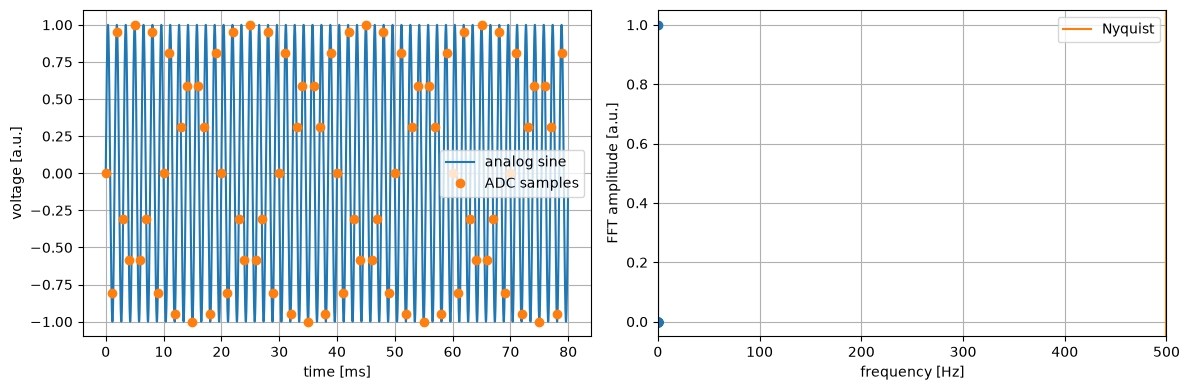

In [5]:
signal_frequency = 650  # Hz
sampling_rate = 1000      # samples per second
duration = 0.08           # seconds

continuous_time = np.linspace(0, duration, 5000, endpoint=False)
continuous_voltage = np.sin(2 * np.pi * signal_frequency * continuous_time)

sample_time = np.arange(0, duration, 1 / sampling_rate)
sample_voltage = np.sin(2 * np.pi * signal_frequency * sample_time)

peak_frequency, peak_amplitude = dominant_fft_peak(sample_voltage, sampling_rate)
print(f"Predicted alias: {alias_frequency(signal_frequency, sampling_rate):.1f} Hz")
print(f"Measured FFT peak: {peak_frequency:.1f} Hz")
print(f"Phase sign: {alias_phase_sign(signal_frequency, sampling_rate)}")

frequency_axis, spectrum = calculate_fft(sample_voltage, sampling_rate)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(continuous_time * 1000, continuous_voltage, label="analog sine")
axes[0].plot(sample_time * 1000, sample_voltage, "o", label="ADC samples")
axes[0].set_xlabel("time [ms]")
axes[0].set_ylabel("voltage [a.u.]")
axes[0].legend()
axes[0].grid(True)

axes[1].stem(frequency_axis, spectrum, basefmt=" ")
axes[1].axvline(sampling_rate / 2, color="C1", label="Nyquist")
axes[1].set_xlabel("frequency [Hz]")
axes[1].set_ylabel("FFT amplitude [a.u.]")
axes[1].set_xlim(0, sampling_rate / 2)
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()


Signal frequency: 100 Hz
Sampling rate: 1000 Hz, Nyquist frequency: 500 Hz
Measured frequency: 100.0 Hz
Phase sign: 1


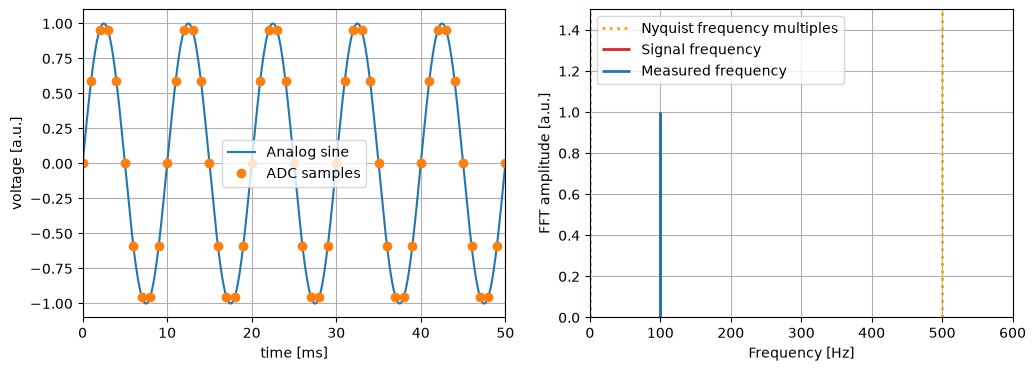

In [39]:
signal_frequency = 100  # Hz
sampling_rate = 1000      # samples per second
duration = 0.08           # seconds

continuous_time = np.linspace(0, duration, 5000, endpoint=False)
continuous_voltage = np.sin(2 * np.pi * signal_frequency * continuous_time)

sample_time = np.arange(0, duration, 1 / sampling_rate)
sample_voltage = np.sin(2 * np.pi * signal_frequency * sample_time)

print(f"Signal frequency: {signal_frequency} Hz")
print(f"Sampling rate: {sampling_rate} Hz, Nyquist frequency: {sampling_rate/2:.0f} Hz")
print(f"Measured frequency: {alias_frequency(signal_frequency, sampling_rate):.1f} Hz")
print(f"Phase sign: {alias_phase_sign(signal_frequency, sampling_rate)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(continuous_time * 1000, continuous_voltage, label="Analog sine")
axes[0].plot(sample_time * 1000, sample_voltage, "o", label="ADC samples")
axes[0].set_xlabel("time [ms]")
axes[0].set_ylabel("voltage [a.u.]")
axes[0].set_xlim(0,5*1000/signal_frequency)
axes[0].legend()
axes[0].grid(True)


true_freq = signal_frequency
measured_freq = alias_frequency(signal_frequency, sampling_rate)
max_freq = signal_frequency + sampling_rate/2 

for i, f in enumerate(np.arange(0, max_freq + sampling_rate/2, sampling_rate/2)):
    axes[1].axvline(f,color="orange",linestyle=":",linewidth=2,label="Nyquist frequency multiples" if i == 1 else None)


axes[1].vlines(true_freq, 0, 1, colors="C3", linewidth=2,label="Signal frequency")
axes[1].vlines(measured_freq, 0, 1, colors="C0", linewidth=2,label="Measured frequency")

axes[1].set_xlim(0, max_freq)
axes[1].set_ylim(0, 1.5)
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("FFT amplitude [a.u.]")
axes[1].legend()
axes[1].grid(True)


#### Demo 2: Anti-aliasing RC filter

A first-order RC low-pass filter placed before the ADC reduces the high harmonics that would otherwise alias. The magnitude response (the fraction of the original signal that is let through the filter) is $|H(f)| = 1 / \sqrt{1 + (f/f_c)^2}$. Change `C` (try 47 nF and 100 nF with R = 10 kΩ) and see which square-wave harmonics are reduced the most before sampling.

In [ ]:
fundamental = 100  # Hz
harmonic_numbers = np.array([1, 3, 5, 7, 9])
harmonic_frequencies = fundamental * harmonic_numbers
harmonic_amplitudes = 1 / harmonic_numbers

R = 10_000
C = 100e-9
cutoff_frequency = 1 / (2 * np.pi * R * C)
filtered_amplitudes = harmonic_amplitudes * rc_lowpass_gain(harmonic_frequencies, cutoff_frequency)

print(f"cutoff frequency: {cutoff_frequency:.1f} Hz")
for k, f, raw, filtered in zip(harmonic_numbers, harmonic_frequencies, harmonic_amplitudes, filtered_amplitudes):
    print(f"k={k:2d}, f={f:5.0f} Hz, before={raw:.3f}, after={filtered:.3f}")

plt.figure(figsize=(8, 4))
plt.stem(harmonic_frequencies, harmonic_amplitudes, linefmt="C0-", markerfmt="C0o", basefmt=" ", label="before RC")
plt.stem(harmonic_frequencies, filtered_amplitudes, linefmt="C1-", markerfmt="C1s", basefmt=" ", label="after RC")
plt.axvline(cutoff_frequency, color="C2", label="cutoff")
plt.xlabel("frequency [Hz]")
plt.ylabel("relative amplitude [a.u.]")
plt.legend()
plt.grid(True)
plt.tight_layout()


#### Demo 3: deliberate undersampling (equivalent-time sampling)

Undersampling (sampling below the Nyquist frequency), normally causes aliasing, resulting in an inaccurate measurement. However, if you need to measure a **repetitive** signal whose frequency is higher than your measurement device's maximum sampling frequency, reconstruction of one complete cycle of the waveform is still possible, even though you are undersampling. To do so, **equivalent-time sampling** can be used. Instead of recording enough samples during a single cycle, the instrument records samples from many repetitions of the same **periodic** signal. Each acquisition is made at a slightly different point/phase of the waveform. Although the sampling rate is below the Nyquist frequency, the repeated waveform allows samples from many periods to be combined to reconstruct one complete cycle. Importantly, this technique only works for **stable, repetitive signals** and cannot be used for single events or signals that change from one cycle to the next.

In [ ]:
# Replace these arrays with your measured time and voltage arrays from Task I3.
signal_frequency = 73  # Hz, example value
period = 1 / signal_frequency

# Example sparse measurement. Delete this block when using real ALPACA data.
example_time = np.arange(0, 0.8, 1 / 120)
example_voltage = np.sin(2 * np.pi * signal_frequency * example_time)

phase, folded_voltage = fold_periodic_samples(example_time, example_voltage, period)

plt.figure(figsize=(8, 4))
plt.plot(phase, folded_voltage, "o", label="folded samples")
plt.xlabel("phase within one period")
plt.ylabel("voltage [a.u.]")
plt.grid(True)
plt.legend()
plt.tight_layout()


### Implement and Investigate
(Task_I1_3_1)=
#### Task I1: Aliasing observed in the time and frequency domains
Connect the output of the function generator to the BNC connector on the ALPACA using a coax (BNC) cable. Connect the shield pin of the BNC connector to the ALPACA ground and connect the signal line to the input of ADC 2 (pin 28). Refer to [ALPACA documentation](.../book/intros/alpaca2/_intro.ipynb) for additional guidance. 

Configure the function generator to output a $50 \mathrm{Hz}$, $2 \mathrm{V_{pp}}$ sine wave with a DC offset of $\mathrm{+ 1 V}$. The result should be a sine wave with values ranging from 0 $\mathrm{V}$ to 2 $\mathrm{V}$. As ADC 2 can only safely read voltages between 0-3V, this falls within its safe voltage range. 

Next, you need to write code to sample the input waveform using ADC 2 at the following sampling rates:
* $f_{s} = 50 \mathrm{Hz}$, $f_{N} = 25 \mathrm{Hz}$
* $f_{s} = 100 \mathrm{Hz}$, $f_{N} = 50 \mathrm{Hz}$
* $f_{s} = 150 \mathrm{Hz}$, $f_{N} = 75 \mathrm{Hz}$
* $f_{s} = 200 \mathrm{Hz}$, $f_{N} = 100 \mathrm{Hz}$

You will take measurements for a total measurement period of 4 seconds. This means for the above sampling rates you will record 200, 400, 600 and 800 points during the measurement period respectively. 

To program the ADC to sample the input signal, first define the measurement pin corresponding to ADC 2. You will then use a for loop to take a specified number of measurements, with one measurement taken during each iteration. Refer to [the ALPACA introduction manuals](.../book/intros/alpaca2/programming.ipynb) for the appropriate functions for defining an ADC pin and taking measurements. To sample at the required sampling rate, the time between consecutive measurements must be equal to the sampling interval, $T_s = \frac{1}{f_s}$, where $f_s$ is the sampling rate. This delay can be implemented using utime.sleep_ms(). 

```{tip}
Because utime.sleep_ms() uses milliseconds, make sure to convert the sampling interval from seconds to milliseconds before using it.
```
Before the for loop, you also need to create a variable to store the measurements. You can either create an array with a length equal to the number of samples or create an empty list. If you use an array, use indexing to store each measurement at the appropriate position. If you use a list, use .append() to add each new measurement to the end of the list.

Plot your recorded samples in the time domain and use the `calculate_fft` function provided in the helper functions in [Simulate](Task_S_3_1) to calculate the Fourier transform of your data so you can plot it in the frequency domain. 

```{tip}
Make sure you copy the `calculate_fft` function and save it in a python file. This function will come in handy in many future assignments! 
```

Fill this table in your notepad:

| True signal frequency | Sampling rate ($f_s$) | Measured signal frequency |
|---:|---:|---:|
| | | 
| | | 
| | | 
| | | 

Deep dive: measuring on the ADC with attenuation 

(Task_I2_3_1)=
#### Task I2: Aliasing of a square wave
```{admonition} Estimated time: 40 min
:class: estimated-time no-content
```
Connect the function generator to one of the BNC connectors on the ALPACA. Connect the Shield pin to the ALPACA ground (GNDA pin) to ground the shield of the coax cable. Configure the function generator to output a 100 $\mathrm{Hz}$, 50% duty cycle square wave. Select an appropriate peak to peak voltage and DC offset such that the signal falls within the safe voltage range on the ADC (0-3 V). 

You will use either ADC 0 or 1 (Pin 26 or 27) in this exercise. Before connecting the signal to the ADC, determine which attenuation setting (1x or 0.1x) is appropriate for your chosen signal. Record your choice and briefly explain why it is appropriate. 

As ADC 0 and 1 take differential measurements, you will need to connect something to both $\mathrm{U_{+}}$ and $\mathrm{U_{-}}$. As your signal is positive, connect the Signal pin of the BNC connector to $\mathrm{U_{+}}$ of your ADC. As there is no negative component of the signal, connect $\mathrm{U_{-}}$ to GNDA. 

You will now need to write code to measure the signal at a sampling rate of $f_{s}=1000 \mathrm{Hz}$. Refer to [the ALPACA manual](.../manuals/intros/alpaca2/programming.ipynb) for guidance on how to define a measurement pin and take a single measurement. To sample at $f_{s}=1000 \mathrm{Hz}$ you will need to take sequential measurements spaced out by $T_{s}=\frac{1}{f_{s}}$. This can be achieved using a loop and `utime.sleep_ms`. 

Use the `calculate_fft` function to calculate the Fourier transform of the signal. Plot the measured signal in both the time and frequency domains. Identify the frequency components present in the measured square wave and compare them with the harmonics you would expect for an ideal 100 Hz, 50% duty cycle square wave. Compare your observations with the predictions you made in [Task A2](Task_A2_3_1).

(Task_I2_3_1)=
#### Task I2: Anti-aliasing RC filter
```{admonition} Estimated time: 20 min
:class: estimated-time no-content
```
Keep the same function generator settings from [Task I1](Task_I1_3_1). 

Construct a low-pass RC filter on the ALPACA using a 10 $\mathrm{k}\Omega$ resistor and either a 47 $\mathrm{nF}$ or 100 $\mathrm{nF}$ capacitor. 

```{tip}
If you need help building the low-pass filter, refer to your lab notes from [1.2 Introduction to the oscilloscope and filters](book/manuals/week1/1.2_intro_to_oscilloscope_and_filters.ipynb). 

Connect the input from the function generator as the input of the filter and connect the output of the filter to the same ADC you used in [Task I1](Task_I1_3_1) (do not change the attenuation you used). Use the same code from [Task I1](Task_I1_3_1) to sample the signal at $f_{s}=1000\mathrm{Hz}$.

Repeat this measurment using the other capacitor. 

```{warning}
Save your recording before running the measurement again, otherwise it will be overrided. If you have an array, you can use `np.save`
```

Use the `calculate_fft` function to calculate the Fourier transform of both recordings. Plot the measured signals in both the time and frequency domains. Identify the frequency components present in the measured square waves and compare them with the harmonics you would expect for an ideal 100 Hz, 50% duty cycle square wave and the signal you measured in [Task I1](Task_I1_3_1). 

How has the signal amplitude been influenced by the two filter? Record your findings in the table below. 

| $C$ | Predicted $f_{c}$ | Effect on aliasing | Effect on shape of signal|
|---:|---:|---:| ---:|
| 47 $\mathrm{nF}$ | | |
| 100 $\mathrm{nF}$| | |


(Task_I3_3_1)=
#### Task I3: Reconstruct a periodic signal by equivalent time sampling
```{admonition} Estimated time: 45 min
:class: estimated-time no-content
```
Connect the function generator to a BNC connector on the ALPACA and connect the signal line to one of the ADC inputs. Configure the function generator to produce a 73 Hz sine wave and select an appropriate amplitude. Take the following points into consideration when selecting the signal amplitude:
- The ADC safely measures voltages in the 0-3 V range. 
- A 0.1x attenuation setting can be applied to ADC 0 and 1, but not ADC 2. This means if attenuation is applied, you can effectively measure a signal from 0-30 V on ADC 0 and 1. 
  
Choose a sampling frequency below the Nyquist rate of 146 Hz for the 73 Hz sine wave. The signal should therefore be deliberately undersampled. Set the total sampling duration to cover 50 complete cycles of the signal.

Plot the sampled signal in the time domain and use `calculate_fft` to plot the signal in the frequency domain. Does the sampled signal exhibit aliasing? Record your observations and explain your findings in your lab notes.

Next, use `fold_periodic_samples` to fold the sampled data onto a single signal period. Plot the measured voltage against phase * period, where phase * period represents the equivalent time position within one cycle.

This phase-folding step is crucial to equivalent-time sampling. Has the waveform been successfully reconstructed after folding the samples onto a single period? Why or why not? Consider how the sampling frequency and the phase relationship between successive samples affect the reconstruction. Do the folded samples cover the full range of phases, or do multiple samples fall at the same or only a limited number of phase positions? Explain how this affects the quality of the reconstructed waveform. Record your findings in your lab notes.

```{admonition} Deep dive (optional)
:class: deep-dive
#### Task I4: Oscilloscope memory and sampling
This is optional enrichment content and is not mandatory for completing the base tasks.

The **Siglent SDS800X HD Series** oscilloscope has a maximum sampling rate of 2 GHz (this is often quoted as 2 GSa/s, as both units are equivalent). However, as the oscilloscope has limited memory, in practice it may have to lower its sampling rate due to memory constraints. You will investigate the effect of this in the following exercise. 

Connect the function generator to the oscilloscope and output a 100 MHz, 1 Vpp sine wave. Record the Nyquist rate for this signal (the minimum sampling rate needed to measure the signal without aliasing). 

Configure the oscilloscope to show exactly 1 full cycle of the sine wave. This corresponds to a horizontal scale of 10 ns/div. Record the sampling rate, number of samples and the appearance of the waveform (i.e. normal or aliased) in the table below. 

```{tip}
The Timebase Descriptor box located on the bottom of the oscilloscope display shows helpful information, such as the horizontal scale, sampling rate and number of samples. 

```{figure} images/Timebase.png
---
width: 500px
name: timebase 
---
```
```

Slowly increase the time-per-division setting (i.e. zoom out of the waveform in time), filling in the table below as you do so. At some point, the displayed waveform may appear to have a frequency lower than its true frequency of 100 MHz. In other words, it may be aliased. 

| Time/div | Acquisition time | Sampling rate | Number of samples | Waveform appearance |
|---:|---:|---:|---:|---:|
| 10 ns/div | 100 ns |  |  |  |
| 20 ns/div | 200 ns |  |  |  |
| 50 ns/div | 500 ns |  |  |  |
| 100 ns/div | 1 µs |  |  |  |
| 200 ns/div | 2 µs |  |  |  |
| 500 ns/div | 5 µs |  |  |  |
| 1 µs/div | 10 µs |  |  |  |

Answer the following questions in your lab notes: 
- At what timebase (time/div) did you first observe aliasing? What was the sampling rate at this point?
- How did the displayed waveform change as you zoomed out?
- Why does the oscilloscope reduce the sampling rate when the acquisition time increases?

```

```{admonition} Deep dive (optional)
:class: deep-dive
#### Task I5: Spectral leakage compensation with window functions 
This is optional enrichment content and is not mandatory for completing the base tasks.

Suppose you are observing the sine wave $x(t)= \mathrm{sin}(2\pi f_0 t)$ on the oscilloscope.  


Emphasise that this can cause unwanted frequencies to appear but isn't aliasing

```

### Compare and conclude

(Task_C1_3_1)=
#### Task C1: Aliasing observed in the time and frequency domain


(Task_C2_3_1)=
#### Task C2: 

(Task_C3_3_1)=
#### Task C3: Equivalent time sampling requirements